In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import PIL
from PIL import Image
import glob
import random

In [2]:
# Parameters
state = None
selected_data_type = None
RESERVED_SHOT = None
EPOCH_NUM = None
VALIDATION_SPLIT = None
ACTIVATION_FUNC = None
LOSS_FUNC = None
OPTIMIZER_FUNC = None
OUTLIER_CUTOFF = None
NUM_CONV2D_LAYERS = None
NUM_DENSE_LAYERS = None
CONV2D_NEURONS = None
CONV2D_SIZE = None
DENSE_LAYER_NEURONS = None
MAX_POOLING_SIZE = None

In [3]:
# Parameters
state = 1
selected_data_type = "ma2"
RESERVED_SHOT = 119671
EPOCH_NUM = 25
VALIDATION_SPLIT = 0.3
ACTIVATION_FUNC = "tanh"
LOSS_FUNC = "mse"
OPTIMIZER_FUNC = "sgd"
OUTLIER_CUTOFF = 100.0
NUM_CONV2D_LAYERS = 1
NUM_DENSE_LAYERS = 1
CONV2D_NEURONS = [16]
CONV2D_SIZE = ["(8, 8)"]
DENSE_LAYER_NEURONS = [16]
MAX_POOLING_SIZE = "(2, 2)"


In [4]:
# Manual override logic
manual = False  # Toggle this to True to use manual values, False to skip

if manual:
    state = 1  # state 1, 2, or 3
    selected_data_type = 'ma2'  # ma2 basically always
    if state == 1:
        RESERVED_SHOT = 119671  # for state 1
    elif state == 2:
        RESERVED_SHOT = 114458  # for state 2
    else:
        RESERVED_SHOT = 119671  # Default for state 3 (choosing one from RESERVED_SHOTS[3])
    EPOCH_NUM = 15  # 15
    VALIDATION_SPLIT = 0.2  # 0.2
    ACTIVATION_FUNC = 'relu'  # 'relu'
    LOSS_FUNC = 'mae'  # 'mae'
    OPTIMIZER_FUNC = 'adam'  # 'adam'
    OUTLIER_CUTOFF = 99  # 99
    NUM_CONV2D_LAYERS = 3  # 3 Conv2D layers
    NUM_DENSE_LAYERS = 2  # 2 dense layer
    CONV2D_NEURONS = [32, 32, 16]  # Neurons per Conv2D layer
    CONV2D_SIZE = [(8, 8), (8, 8), (4, 4)]  # Kernel sizes for Conv2D layers
    DENSE_LAYER_NEURONS = [64, 32]  # Neurons for dense layer
    MAX_POOLING_SIZE = (2, 2)  # Max pooling size

    # Update parameters dictionary for Papermill
    parameters = {
        'state': state,
        'selected_data_type': selected_data_type,
        'RESERVED_SHOT': RESERVED_SHOT,
        'EPOCH_NUM': EPOCH_NUM,
        'VALIDATION_SPLIT': VALIDATION_SPLIT,
        'ACTIVATION_FUNC': ACTIVATION_FUNC,
        'LOSS_FUNC': LOSS_FUNC,
        'OPTIMIZER_FUNC': OPTIMIZER_FUNC,
        'OUTLIER_CUTOFF': OUTLIER_CUTOFF,
        'NUM_CONV2D_LAYERS': NUM_CONV2D_LAYERS,
        'NUM_DENSE_LAYERS': NUM_DENSE_LAYERS,
        'CONV2D_NEURONS': CONV2D_NEURONS,
        'CONV2D_SIZE': CONV2D_SIZE,
        'DENSE_LAYER_NEURONS': DENSE_LAYER_NEURONS,
        'MAX_POOLING_SIZE': MAX_POOLING_SIZE
    }

In [5]:
# Define shot lists and paths
SHOT_PATHS = {
    'new_shots': {
        'range': (119591, 119769),
        'data_path': '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/Input Data/Shots/',
        'hbt_path': '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/python_hbteplib_data/',
        'ip_path': '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/ip_Data/'
    },
    'old_shots': {
        'range': (114407, 114473),
        'data_path': '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/Input Data/Old Shots/',
        'hbt_path': '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/oldshot_python_hbteplib_data/',
        'ip_path': '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/oldshot_python_hbteplib_data/'
    }
}

#state = 2  # 1: new shots, 2: old shots, 3: combined
if state == 1:
    shot_list = [119591, 119599, 119601, 119646, 119648, 119653, 119654, 119658, 119659,
                 119661, 119662, 119663, 119665, 119666, 119667, 119669, 119670, 119671,
                 119673, 119675, 119748, 119750, 119751, 119752, 119754, 119755, 119756,
                 119757, 119760, 119761, 119762, 119763, 119764, 119766, 119767, 119768, 119769]
elif state == 2:
    shot_list = [114407, 114408, 114411, 114412, 114413, 114415, 114416, 114417, 114418, 114419,
                 114420, 114422, 114424, 114425, 114428, 114429, 114431, 114432, 114433, 114434,
                 114435, 114436, 114438, 114439, 114441, 114443, 114444, 114445, 114448, 114450,
                 114451, 114453, 114454, 114455, 114456, 114457, 114458, 114460, 114462, 114464,
                 114467, 114468, 114472, 114473]
elif state == 3:
    shot_list = [119591, 119599, 119601, 119646, 119648, 119653, 119654, 119658, 119659,
                 119661, 119662, 119663, 119665, 119666, 119667, 119669, 119670, 119671,
                 119673, 119675, 119748, 119750, 119751, 119752, 119754, 119755, 119756,
                 119757, 119760, 119761, 119762, 119763, 119764, 119766, 119767, 119768, 119769,
                 114407, 114408, 114411, 114412, 114413, 114415, 114416, 114417, 114418, 114419,
                 114420, 114422, 114424, 114425, 114428, 114429, 114431, 114432, 114433, 114434,
                 114435, 114436, 114438, 114439, 114441, 114443, 114444, 114445, 114448, 114450,
                 114451, 114453, 114454, 114455, 114456, 114457, 114458, 114460, 114462, 114464,
                 114467, 114468, 114472, 114473]

#selected_data_type = 'ma2'  # Options: 'ma1', 'ma2', 'ma3', 'ma4', 'mp1', 'mp2', 'mp3', 'mp4'
# Notebook type definition
notebook_type = 'trimmed'  # Set to 'trimmed' or 'untrimmed' based on the notebook
CAMERA_DEPTH = 65535.0  # 2^16
DEFAULT_FRAME_COUNT = 800
#RESERVED_SHOT = 114458  # Will be set randomly after valid_shots is created if None

def get_paths_for_shot(shot_num):
    """Return data, HBT, and IP paths for a given shot number."""
    for paths in SHOT_PATHS.values():
        if paths['range'][0] <= shot_num <= paths['range'][1]:
            return paths['data_path'], paths['hbt_path'], paths['ip_path']
    raise ValueError(f"Shot number {shot_num} is not in the defined ranges.")

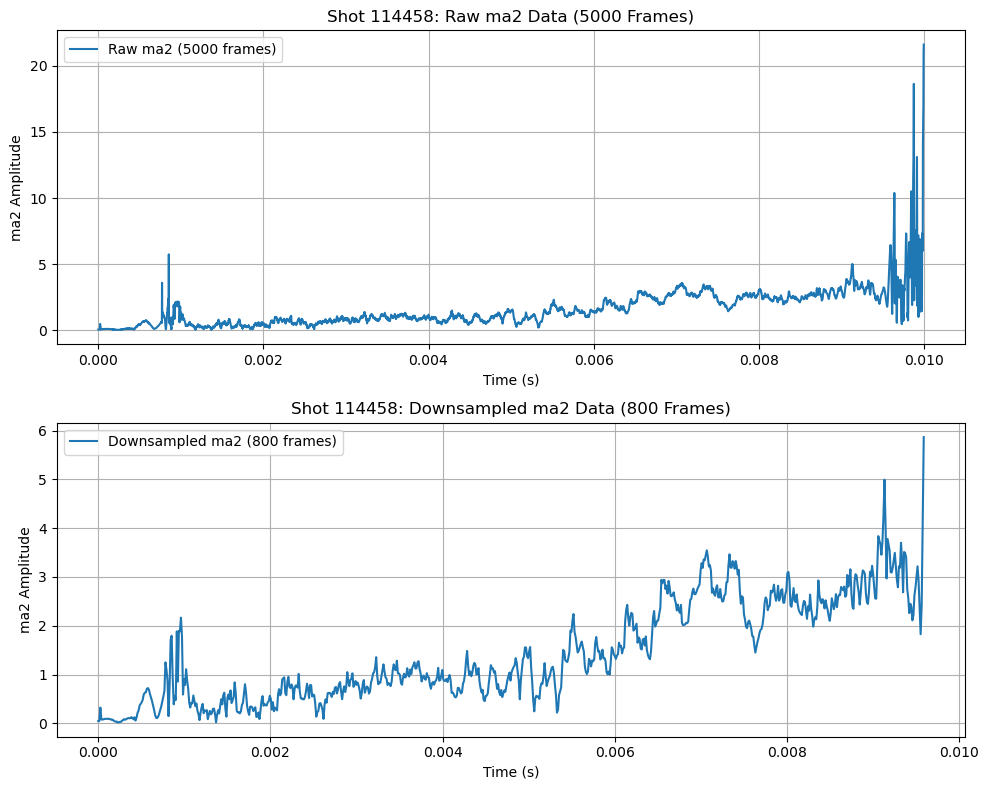

Raw ma2 data: 5000 frames
Downsampled ma2 data: 800 frames
Raw time data: 5000 frames
Downsampled time data: 800 frames


In [6]:
# Define paths and parameters from the script
hbt_path = '/Users/aboeckmann/Documents/Columbia/PlasmaLab/HBT-EP-Boeckmann/HighFreqMLModeling/Training/oldshot_python_hbteplib_data/'
shot = 114458
DEFAULT_FRAME_COUNT = 800

# Load raw HBT ma2 and time data
ma2_data = np.load(os.path.join(hbt_path, f'{shot}m2Amp.npy'))
time_data = np.load(os.path.join(hbt_path, f'{shot}time.npy'))

# Downsample to 800 frames (as in untrimmed script)
frame_ratio = len(ma2_data) // DEFAULT_FRAME_COUNT  # 5000 // 800 = 6
downsampled_ma2 = ma2_data[::frame_ratio][:DEFAULT_FRAME_COUNT]
downsampled_time = time_data[::frame_ratio][:DEFAULT_FRAME_COUNT]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

# Plot 1: Raw 5000 frames
ax1.plot(time_data, ma2_data, label='Raw ma2 (5000 frames)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('ma2 Amplitude')
ax1.set_title(f'Shot {shot}: Raw ma2 Data (5000 Frames)')
ax1.legend()
ax1.grid(True)

# Plot 2: Downsampled 800 frames
ax2.plot(downsampled_time, downsampled_ma2, label='Downsampled ma2 (800 frames)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('ma2 Amplitude')
ax2.set_title(f'Shot {shot}: Downsampled ma2 Data (800 Frames)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print frame counts for confirmation
print(f"Raw ma2 data: {len(ma2_data)} frames")
print(f"Downsampled ma2 data: {len(downsampled_ma2)} frames")
print(f"Raw time data: {len(time_data)} frames")
print(f"Downsampled time data: {len(downsampled_time)} frames")

In [7]:
def smooth_data(data, window_size=5):
    """Smooth data using a moving average with edge padding."""
    smoothed = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    pad = window_size // 2
    smoothed = np.pad(smoothed, (pad, pad), mode='edge')
    return smoothed[:len(data)]

def load_ip_data(shot_list):
    """Load IP data for given shots, handling missing files."""
    ip_data = []
    for shot in shot_list:
        _, _, ip_path = get_paths_for_shot(shot)
        try:
            ip_data.append(np.load(os.path.join(ip_path, f'{shot}ip.npy')))
        except FileNotFoundError:
            print(f"IP data file for shot {shot} not found. Skipping.")
    return ip_data

def format_ip_data(data, target_length=DEFAULT_FRAME_COUNT):
    """Format IP data to target length and shape."""
    data = np.asarray(data, dtype=float)
    frame_ratio = data[0].shape[0] // target_length
    return data[:, ::frame_ratio, np.newaxis][:,:target_length,:]

def find_initial_cutoff_index(ip_data, window_size=5, start_index=50):
    """Find initial cutoff index based on peak and valley detection."""
    smoothed_ip = smooth_data(ip_data, window_size)
    diff = np.diff(smoothed_ip)
    
    for i in range(start_index, len(diff)):
        if diff[i-1] > 0 and diff[i] < 0 and ip_data[i] > 0:
            peak_index = i
            for j in range(peak_index + 1, len(diff)):
                if diff[j-1] < 0 and diff[j] > 0 and ip_data[j] > 0:
                    return j
            return peak_index
    return 0

def find_end_cutoff_index(ip_data, window_size=5, jump_ratio=2.5, lookback_window=10, stability_window=30):
    """Find end cutoff index based on derivative jumps."""
    smoothed_ip = smooth_data(ip_data, window_size)
    diff = np.diff(smoothed_ip)
    
    baseline_median = np.median(diff[:stability_window]) if len(diff) > stability_window else np.median(diff)
    
    for i in range(stability_window, len(diff) - lookback_window):
        if np.max(diff[i:i + lookback_window]) > jump_ratio * abs(baseline_median) and diff[i] < 0.2 * np.max(diff[i:i + lookback_window]):
            return max(0, i - window_size)
    for i in range(stability_window, len(diff)):
        if diff[i] < -jump_ratio * abs(baseline_median):
            return max(0, i - window_size)
    return len(ip_data)

# Process IP data
ip_data = load_ip_data(shot_list)
formatted_ip_data = format_ip_data(ip_data)

initial_cutoff_indices = [find_initial_cutoff_index(formatted_ip_data[i, :, 0]) for i in range(len(shot_list))]
end_cutoff_indices = [
    find_end_cutoff_index(formatted_ip_data[i, initial_cutoff_indices[i]:, 0]) + initial_cutoff_indices[i]
    if find_end_cutoff_index(formatted_ip_data[i, initial_cutoff_indices[i]:, 0]) < len(formatted_ip_data[i, initial_cutoff_indices[i]:, 0])
    else DEFAULT_FRAME_COUNT
    for i in range(len(shot_list))
]
frame_counts = [end - start for end, start in zip(end_cutoff_indices, initial_cutoff_indices)]

In [8]:
def process_shot_data(folder_path, initial_cutoff, end_cutoff, max_pixel_value=CAMERA_DEPTH):
    """Process TIFF images in a folder, cropping to 32x32 and normalizing."""
    tiff_files = sorted(glob.glob(os.path.join(folder_path, "*.tiff")))
    if not tiff_files:
        raise ValueError(f"No TIFF files found in {folder_path}")
    
    end_cutoff = min(end_cutoff, len(tiff_files))
    if initial_cutoff >= end_cutoff:
        raise ValueError(f"Invalid cutoff indices: initial={initial_cutoff}, end={end_cutoff}")
    
    shot_2d = []
    for tiff_file in tiff_files[initial_cutoff:end_cutoff]:
        try:
            with Image.open(tiff_file) as im:
                img = np.array(im, dtype=np.float32) / max_pixel_value
                h, w = img.shape
                if h < 32 or w < 32:
                    raise ValueError(f"Image too small to crop to 32x32: got {h}x{w}")
                
                start_h, start_w = (h - 32) // 2, (w - 32) // 2
                cropped = img[start_h:start_h + 32, start_w:start_w + 32]
                shot_2d.append(cropped)
        except Exception as e:
            print(f"Error loading {tiff_file}: {e}")
            continue
    
    if not shot_2d:
        raise ValueError(f"No valid frames processed for {folder_path}")
    
    shot_2d = np.array(shot_2d)
    return shot_2d, shot_2d, shot_2d.reshape(len(shot_2d), -1), len(shot_2d)

def process_all_shots(shot_list, initial_cutoff_indices, end_cutoff_indices, frame_counts):
    """Process all shots, returning 2D, cut, flat data, valid shots, and frame counts."""
    training_data_2D, cut_training_data_2D, flat_training_data = [], [], []
    valid_shots, actual_frame_counts = [], []
    
    for i, shot in enumerate(shot_list):
        if shot == RESERVED_SHOT:
            continue
        data_path, _, _ = get_paths_for_shot(shot)
        folder_path = os.path.join(data_path, str(shot), 'CAM-26731/tiff/')
        try:
            shot_2d, cut_2d, flat_data, actual_frames = process_shot_data(
                folder_path, initial_cutoff_indices[i], end_cutoff_indices[i]
            )
            if actual_frames > 0:
                training_data_2D.append(shot_2d)
                cut_training_data_2D.append(cut_2d)
                flat_training_data.append(flat_data)
                valid_shots.append(shot)
                actual_frame_counts.append(actual_frames)
            else:
                print(f"Shot {shot} produced 0 frames. Skipping.")
        except Exception as e:
            print(f"Error processing shot {shot}: {e}")
    
    return training_data_2D, cut_training_data_2D, flat_training_data, valid_shots, actual_frame_counts


# Process all shots
training_data_2D, cut_training_data_2D, flat_training_data, valid_shots, actual_frame_counts = process_all_shots(
    shot_list, initial_cutoff_indices, end_cutoff_indices, frame_counts
)

# Process RESERVED_SHOT separately for testing
reserved_shot_data_2d = None
reserved_shot_cut_2d = None
reserved_shot_flat = None
reserved_shot_frame_count = None
if RESERVED_SHOT is not None:
    shot_idx = shot_list.index(RESERVED_SHOT)
    data_path, _, _ = get_paths_for_shot(RESERVED_SHOT)
    folder_path = os.path.join(data_path, str(RESERVED_SHOT), 'CAM-26731/tiff/')
    
    print(f"RESERVED_SHOT {RESERVED_SHOT}: initial_cutoff={initial_cutoff_indices[shot_idx]}, end_cutoff={end_cutoff_indices[shot_idx]}")
    
    try:
        shot_2d, cut_2d, flat_data, actual_frames = process_shot_data(
            folder_path, initial_cutoff_indices[shot_idx], end_cutoff_indices[shot_idx]
        )
        print(f"RESERVED_SHOT {RESERVED_SHOT}: actual_frames={actual_frames}")
        # Rest of the block...
        reserved_shot_data_2d = shot_2d
        reserved_shot_cut_2d = cut_2d
        reserved_shot_flat = flat_data
        reserved_shot_frame_count = actual_frames
        print(f"Successfully processed RESERVED_SHOT {RESERVED_SHOT} with {actual_frames} frames")

    except Exception as e:
        print(f"Error processing RESERVED_SHOT {RESERVED_SHOT}: {e}")

# Set RESERVED_SHOT if None
if RESERVED_SHOT is None:
    RESERVED_SHOT = random.choice(valid_shots)
    print(f"Randomly selected reserved shot: {RESERVED_SHOT}")
    shot_idx = shot_list.index(RESERVED_SHOT)
    data_path, _, _ = get_paths_for_shot(RESERVED_SHOT)
    folder_path = os.path.join(data_path, str(RESERVED_SHOT), 'CAM-26731/tiff/')
    shot_2d, cut_2d, flat_data, actual_frames = process_shot_data(
        folder_path, initial_cutoff_indices[shot_idx], end_cutoff_indices[shot_idx]
    )
    reserved_shot_data_2d = shot_2d
    reserved_shot_cut_2d = cut_2d
    reserved_shot_flat = flat_data
    reserved_shot_frame_count = actual_frames

RESERVED_SHOT 119671: initial_cutoff=88, end_cutoff=465
RESERVED_SHOT 119671: actual_frames=377
Successfully processed RESERVED_SHOT 119671 with 377 frames


In [9]:
def format_hbt_data(data, mode_num, initial_cutoffs, end_cutoffs, frame_ratio):
    """Format HBT data for a given mode, trimming to scaled cutoff indices."""
    formatted = []
    for shot in valid_shots:
        idx = shot_list.index(shot)
        initial = initial_cutoffs[idx] * frame_ratio
        end = min(end_cutoffs[idx] * frame_ratio, len(data[idx][mode_num-1]))
        hbt_slice = data[idx][mode_num-1][initial:end].reshape(-1, 1)
        formatted.append(hbt_slice)
    return formatted

raw_target_vector = []
frame_ratio = ip_data[0].shape[0] // DEFAULT_FRAME_COUNT  # Original length (5000) to target length (800)
for i, shot in enumerate(valid_shots):
    if shot == RESERVED_SHOT:
        continue
    _, hbt_path, _ = get_paths_for_shot(shot)
    ma2_data = np.load(os.path.join(hbt_path, f'{shot}m2Amp.npy'))
    initial = initial_cutoff_indices[i] * frame_ratio
    end = min(end_cutoff_indices[i] * frame_ratio, len(ma2_data))
    ma2_data = ma2_data[initial:end]
    hbt_frame_ratio = (end - initial) // actual_frame_counts[i] if actual_frame_counts[i] > 0 else 1
    ma2_data = ma2_data[::hbt_frame_ratio][:actual_frame_counts[i]]
    raw_target_vector.extend(ma2_data)

raw_target_vector = np.asarray(raw_target_vector, dtype=np.float32)
percentile_99 = np.percentile(np.abs(raw_target_vector), 90)
ma_norm = percentile_99 if percentile_99 > 0 else 1.0
outlier_threshold = 3 * ma_norm
print(f"Normalization factor (99th percentile): {ma_norm:.2f}")
print(f"Number of outliers (|value| > {outlier_threshold:.2f}): {np.sum(np.abs(raw_target_vector) > outlier_threshold)}")

def load_hbt_data(shot_list, valid_shots, initial_cutoff_indices, end_cutoff_indices, reserved_shot=RESERVED_SHOT, reserved_frame_count=None, ma_norm=None):
    """Load and format HBT amplitude, phase, and time data, with proper scaling of cutoff indices."""
    hbt_data = {'amplitudes': [], 'phases': [], 'times': []}
    
    # Define frame ratio used in IP data downsampling
    frame_ratio = ip_data[0].shape[0] // DEFAULT_FRAME_COUNT  # Original length (5000) to target length (800)
    
    for shot in shot_list:
        _, hbt_path, _ = get_paths_for_shot(shot)
        modes = {
            f'mode_{m}': {
                'amp': np.load(os.path.join(hbt_path, f'{shot}m{m}Amp.npy')),
                'phase': np.load(os.path.join(hbt_path, f'{shot}m{m}Phase.npy'))
            } for m in range(1, 5)
        }
        hbt_data['amplitudes'].append([modes[f'mode_{m}']['amp'] for m in range(1, 5)])
        hbt_data['phases'].append([modes[f'mode_{m}']['phase'] for m in range(1, 5)])
        hbt_data['times'].append(np.load(os.path.join(hbt_path, f'{shot}time.npy')))
    
    # Format data for valid shots
    formatted_data = {
        'amplitudes': [format_hbt_data(hbt_data['amplitudes'], m, initial_cutoff_indices, end_cutoff_indices, frame_ratio) for m in range(1, 5)],
        'phases': [format_hbt_data(hbt_data['phases'], m, initial_cutoff_indices, end_cutoff_indices, frame_ratio) for m in range(1, 5)],
        'times': [
            hbt_data['times'][shot_list.index(shot)][initial_cutoff_indices[shot_list.index(shot)]*frame_ratio:end_cutoff_indices[shot_list.index(shot)]*frame_ratio]
            for shot in valid_shots
        ]
    }
    
    # Process reserved shot separately if it exists and has a frame count
    reserved_shot_hbt = None
    reserved_shot_time = None
    if reserved_shot is not None and reserved_frame_count is not None:
        idx = shot_list.index(reserved_shot)
        initial = initial_cutoff_indices[idx] * frame_ratio  # Scale to original frames
        end = min(end_cutoff_indices[idx] * frame_ratio, len(hbt_data['times'][idx]))  # Ensure not exceeding data length
        # Select the appropriate mode data based on selected_data_type
        mode_index = {'ma1': 0, 'ma2': 1, 'ma3': 2, 'ma4': 3, 'mp1': 0, 'mp2': 1, 'mp3': 2, 'mp4': 3}
        data_type = 'amplitudes' if selected_data_type.startswith('ma') else 'phases'
        mode_num = mode_index[selected_data_type]
        hbt_data_selected = hbt_data[data_type][idx][mode_num]
        # Trim HBT data
        reserved_shot_hbt = hbt_data_selected[initial:end]
        # Downsample to match camera frame count
        hbt_frame_ratio = (end - initial) // reserved_frame_count if reserved_frame_count > 0 else 1
        reserved_shot_hbt = reserved_shot_hbt[::hbt_frame_ratio][:reserved_frame_count]
        # Normalize using the same ma_norm as training data
        if ma_norm is not None:
            clipped_count = np.sum(reserved_shot_hbt > 3 * ma_norm) + np.sum(reserved_shot_hbt < -3 * ma_norm)
            print(f"RESERVED_SHOT {reserved_shot}: {clipped_count} values clipped out of {len(reserved_shot_hbt)}")
            reserved_shot_hbt = np.clip(reserved_shot_hbt, -3 * ma_norm, 3 * ma_norm) / ma_norm
        reserved_shot_hbt = reserved_shot_hbt.reshape(-1, 1)
        # Trim and downsample time data
        reserved_shot_time = hbt_data['times'][idx][initial:end][::hbt_frame_ratio][:reserved_frame_count]
        print(f"RESERVED_SHOT {reserved_shot}: HBT {selected_data_type} frames={len(reserved_shot_hbt)}")
        print(f"RESERVED_SHOT {reserved_shot}: Time data frames={len(reserved_shot_time)}")
    
    return formatted_data, reserved_shot_hbt, reserved_shot_time

# Update the call to load_hbt_data with ma_norm
hbt_data, reserved_shot_hbt, reserved_shot_time = load_hbt_data(
    shot_list, valid_shots, initial_cutoff_indices, end_cutoff_indices, 
    reserved_shot=RESERVED_SHOT, reserved_frame_count=reserved_shot_frame_count, ma_norm=ma_norm
)

Normalization factor (99th percentile): 3.59
Number of outliers (|value| > 10.78): 41
RESERVED_SHOT 119671: 0 values clipped out of 377
RESERVED_SHOT 119671: HBT ma2 frames=377
RESERVED_SHOT 119671: Time data frames=377


Normalization factor (100.0 percentile): 5.71
Number of outliers (|value| > 17.14): 0
Saved normalization info to normalization_trimmed_state_1.npz
Training shape: (12460, 32, 32, 1) Target shape: (12460,)
Testing shape: (400, 32, 32, 1) Testing label shape: (400,)


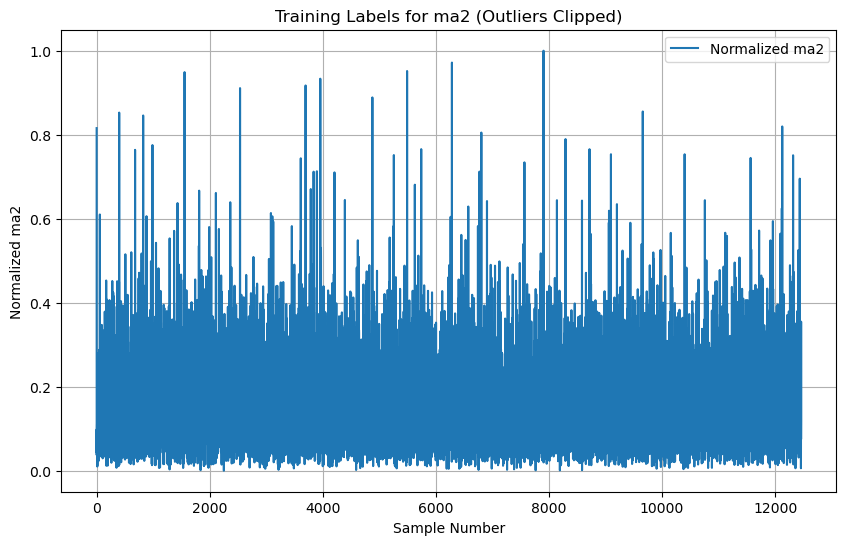

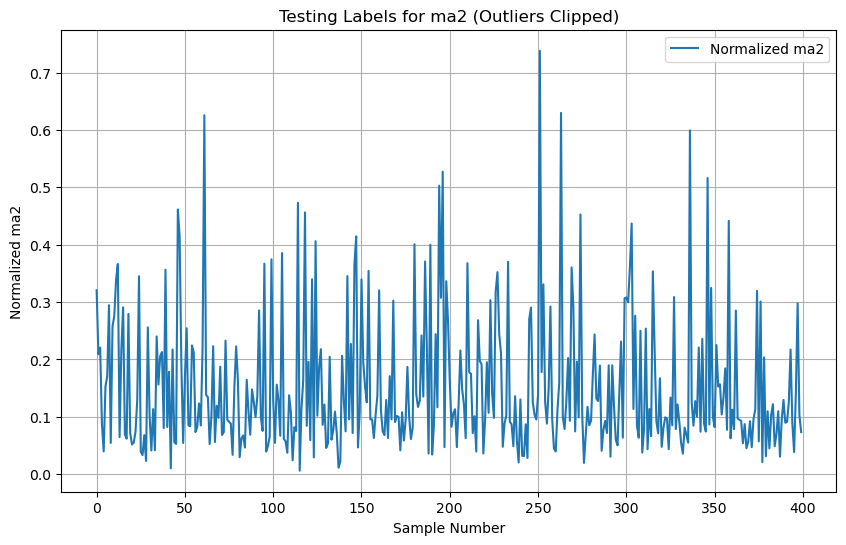

ma_norm: 5.712442874908447
Raw target min/max: 0.002442575292661786, 5.712442874908447
Clipped target min/max: 0.002442575292661786, 5.712442874908447
Reserved shot ma2 min/max: 0.008425971379601334, 2.0253574501339218


In [10]:
# Define data_type_mapping
hbt_ma1_data, hbt_ma2_data, hbt_ma3_data, hbt_ma4_data = hbt_data['amplitudes']
hbt_mp1_data, hbt_mp2_data, hbt_mp3_data, hbt_mp4_data = hbt_data['phases']
hbt_time_data = hbt_data['times']

data_type_mapping = {
    'ma1': hbt_ma1_data,
    'ma2': hbt_ma2_data,
    'ma3': hbt_ma3_data,
    'ma4': hbt_ma4_data,
    'mp1': hbt_mp1_data,
    'mp2': hbt_mp2_data,
    'mp3': hbt_mp3_data,
    'mp4': hbt_mp4_data
}

if selected_data_type not in data_type_mapping:
    raise ValueError(f"Invalid selected_data_type: {selected_data_type}. Choose from {list(data_type_mapping.keys())}")

# Prepare data for HBT prediction model
target_data = data_type_mapping[selected_data_type]  # Use selected data type as target
training_data = cut_training_data_2D

# Normalization factors
camera_norm = 1  # Camera data already normalized by max_pixel_value
# Use percentile-based normalization to handle outliers
raw_target_vector = []
for i, shot in enumerate(valid_shots):
    if shot == RESERVED_SHOT:
        continue
    for j in range(actual_frame_counts[i]):
        raw_target_vector.append(target_data[i][j])

# Convert to numpy array for analysis
raw_target_vector = np.asarray(raw_target_vector, dtype=np.float32)[:, 0]

# Check for outliers
percentile_cutoff = np.percentile(np.abs(raw_target_vector), OUTLIER_CUTOFF) #99%
ma_norm = percentile_cutoff if percentile_cutoff > 0 else 1.0  # Use 99th percentile for normalization
outlier_threshold = 3 * ma_norm  # Define outliers as values > 3 * normalization factor
outliers = np.abs(raw_target_vector) > outlier_threshold
print(f"Normalization factor ({OUTLIER_CUTOFF} percentile): {ma_norm:.2f}")
print(f"Number of outliers (|value| > {outlier_threshold:.2f}): {np.sum(outliers)}")

# Clip outliers for normalization
raw_target_vector = np.clip(raw_target_vector, -outlier_threshold, outlier_threshold)

# Reshape the training data and labels, excluding RESERVED_SHOT
target_vector = []
training_vector = []
for i, shot in enumerate(valid_shots):
    if shot == RESERVED_SHOT:
        continue
    for j in range(actual_frame_counts[i]):
        target_vector.append(target_data[i][j])
        training_vector.append(training_data[i][j])

# Shuffle the data
random.seed(123)
zip_list = list(zip(target_vector, training_vector))
random.shuffle(zip_list)
target_vector, training_vector = zip(*zip_list)

# Convert to numpy arrays and normalize with clipping
target_vector = np.asarray(target_vector, dtype=np.float32)[:, 0]
target_vector = np.clip(target_vector, -outlier_threshold, outlier_threshold) / ma_norm
training_vector = np.asarray(training_vector, dtype=np.float32).reshape(-1, 32, 32, 1)

# Split into training and testing sets
test_size = 400
testing_inputs = training_vector[-test_size:]
testing_labels = target_vector[-test_size:]
training_vector = training_vector[:-test_size]
target_vector = target_vector[:-test_size]

# Save normalization info to a per-run file
normalization_filename = f"normalization_{notebook_type}_state_{state}.npz"
np.savez(normalization_filename,
         ma_norm=ma_norm,
         outlier_threshold=outlier_threshold,
         selected_data_type=selected_data_type)
print(f"Saved normalization info to {normalization_filename}")


print('Training shape:', training_vector.shape, 'Target shape:', target_vector.shape)
print('Testing shape:', testing_inputs.shape, 'Testing label shape:', testing_labels.shape)

# Plot training labels
plt.figure(figsize=(10, 6))
plt.plot(target_vector, label=f'Normalized {selected_data_type}')
plt.xlabel('Sample Number')
plt.ylabel(f'Normalized {selected_data_type}')
plt.title(f'Training Labels for {selected_data_type} (Outliers Clipped)')
plt.grid(True)
plt.legend()
plt.show()

# Plot testing labels
plt.figure(figsize=(10, 6))
plt.plot(testing_labels, label=f'Normalized {selected_data_type}')
plt.xlabel('Sample Number')
plt.ylabel(f'Normalized {selected_data_type}')
plt.title(f'Testing Labels for {selected_data_type} (Outliers Clipped)')
plt.grid(True)
plt.legend()
plt.show()


print(f"ma_norm: {ma_norm}")
print(f"Raw target min/max: {np.min(raw_target_vector)}, {np.max(raw_target_vector)}")
print(f"Clipped target min/max: {np.min(target_vector * ma_norm)}, {np.max(target_vector * ma_norm)}")
print(f"Reserved shot ma2 min/max: {np.min(reserved_shot_hbt[:, 0])}, {np.max(reserved_shot_hbt[:, 0])}")

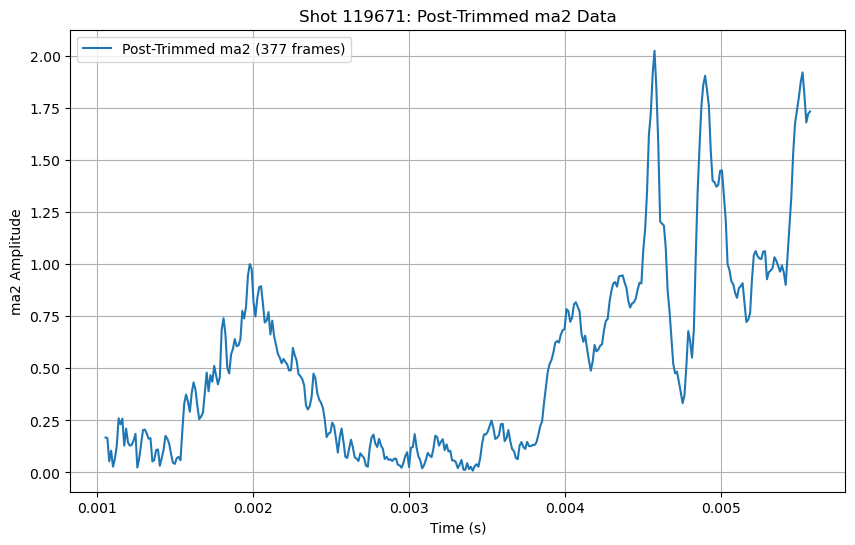

Post-trimmed ma2 data: 377 frames
Post-trimmed time data: 377 frames


In [11]:
# Plot post-trimmed ma2 data for RESERVED_SHOT
if reserved_shot_hbt is not None and reserved_shot_time is not None:
    # Create figure for post-trimmed data
    plt.figure(figsize=(10, 6))
    plt.plot(reserved_shot_time, reserved_shot_hbt[:, 0], label=f'Post-Trimmed ma2 ({len(reserved_shot_hbt)} frames)')
    plt.xlabel('Time (s)')
    plt.ylabel('ma2 Amplitude')
    plt.title(f'Shot {RESERVED_SHOT}: Post-Trimmed ma2 Data')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print frame counts for confirmation
    print(f"Post-trimmed ma2 data: {len(reserved_shot_hbt)} frames")
    print(f"Post-trimmed time data: {len(reserved_shot_time)} frames")
else:
    print(f"No post-trimmed data available for shot {RESERVED_SHOT}")

In [12]:
import ast

# Define model architecture
num_conv2d_layers = NUM_CONV2D_LAYERS
num_dense_layers = NUM_DENSE_LAYERS

conv2d_neurons = CONV2D_NEURONS
conv2d_size = CONV2D_SIZE 
dense_layer_neurons = DENSE_LAYER_NEURONS 
max_pooling_size = MAX_POOLING_SIZE 
activation_func = ACTIVATION_FUNC 
loss_func = LOSS_FUNC 
optimizer_func = OPTIMIZER_FUNC 

# Reinterpret conv2d_size to handle various input formats
conv2d_size = [
    tuple(int(x) for x in ast.literal_eval(size) if isinstance(x, (int, float)))
    if isinstance(size, str) else tuple(int(x) for x in size)
    for size in conv2d_size
]
# Reinterpret max_pooling_size to handle various input formats
max_pooling_size = (
    tuple(int(x) for x in ast.literal_eval(max_pooling_size) if isinstance(x, (int, float)))
    if isinstance(max_pooling_size, str) else tuple(int(x) for x in max_pooling_size)
)

# Create the model
william_model = tf.keras.models.Sequential()

# Add input layer
william_model.add(tf.keras.layers.InputLayer(shape=(32, 32, 1)))

# Add Conv2D layers
for i in range(num_conv2d_layers):
    william_model.add(tf.keras.layers.Conv2D(conv2d_neurons[i], conv2d_size[i], padding='same', activation=activation_func))
    william_model.add(tf.keras.layers.MaxPooling2D(max_pooling_size, padding='same'))

# Flatten the output
william_model.add(tf.keras.layers.Flatten())

# Add dense layers
for i in range(num_dense_layers):
    william_model.add(tf.keras.layers.Dense(dense_layer_neurons[i], activation=activation_func))
    william_model.add(tf.keras.layers.Dropout(0.2))  # Add dropout to prevent overfitting

# Output layer
william_model.add(tf.keras.layers.Dense(1))

# Compile the model
william_model.compile(optimizer=optimizer_func, loss=loss_func)

# Display model summary
william_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        65,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,609 (260.19 KB)

 Trainable params: 66,609 (260.19 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the model
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=30)
Model = william_model
history = Model.fit(training_vector, target_vector,
                    epochs=EPOCH_NUM,
                    validation_split=VALIDATION_SPLIT,
                    batch_size=32,
                    verbose=1,
                    callbacks=[early_stop])


Epoch 1/25


  1/273 ━━━━━━━━━━━━━━━━━━━━ 39s 144ms/step - loss: 0.0722

 10/273 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9123   

 20/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7467

 27/273 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6508

...

241/273 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097

251/273 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0097

261/273 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096

270/273 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0096 - val_loss: 0.0085


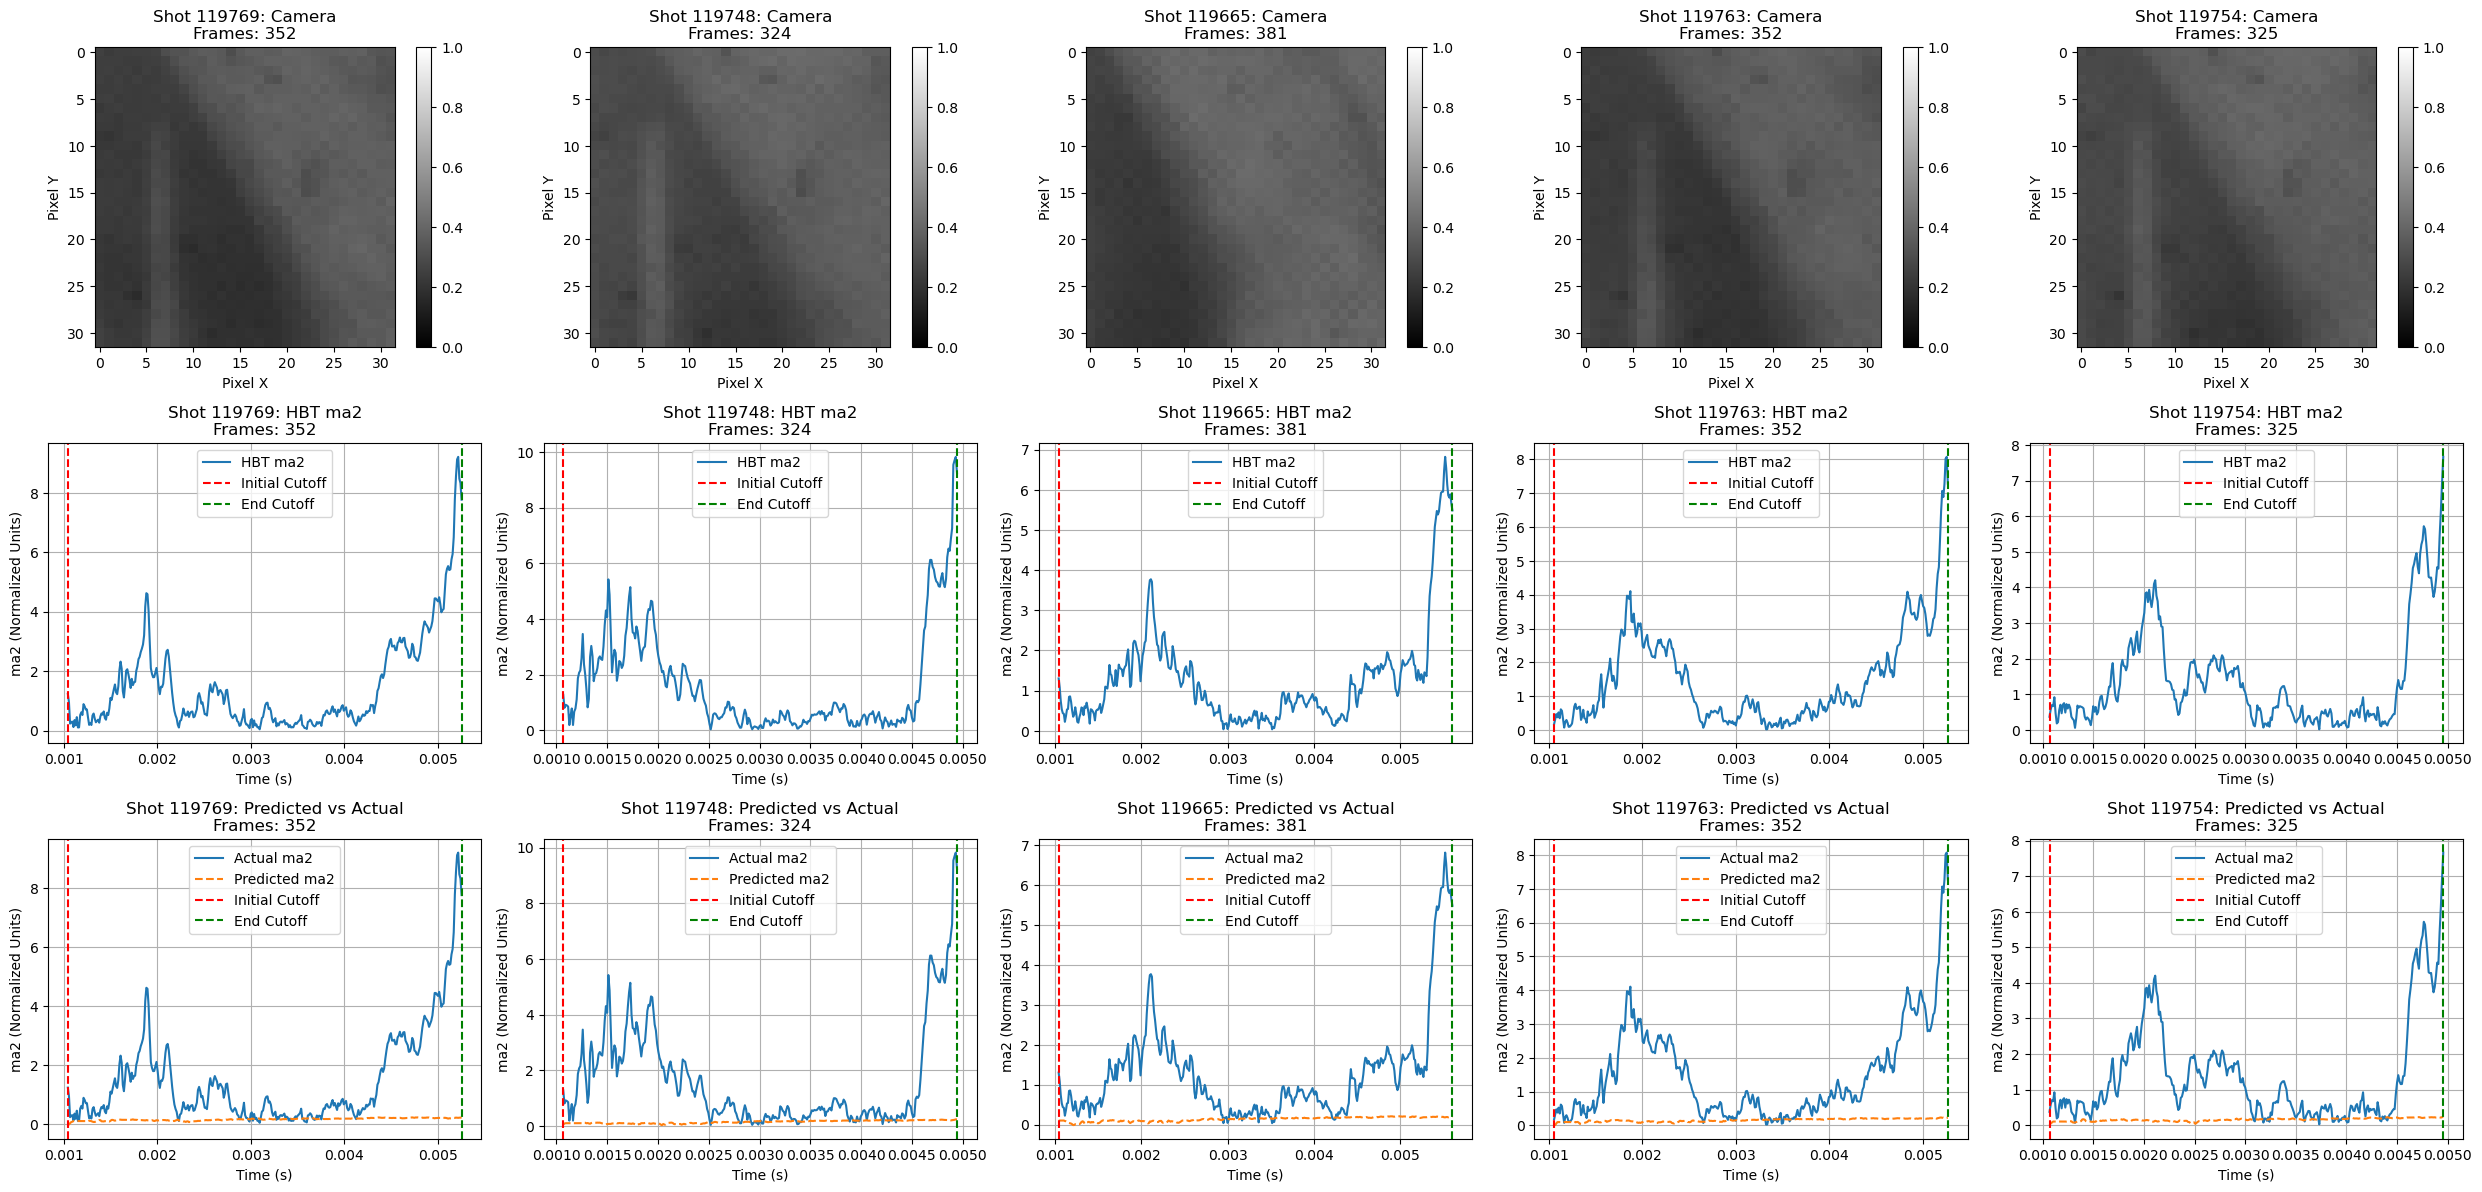

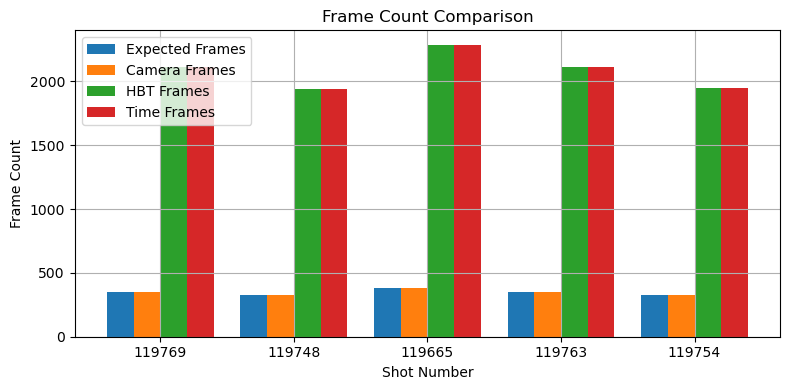

In [14]:
def visualize_non_ip_data(shot_list, valid_shots, cut_training_data_2D, target_data, hbt_time_data, 
                         initial_cutoff_indices, end_cutoff_indices, actual_frame_counts, num_shots_to_plot, model, ma_norm):
    """
    Visualize camera, HBT mode amplitude/phase, and predicted vs actual data in normalized units.
    Downsamples HBT and time data to match camera frame counts.
    """
    # Randomly select shots to plot, excluding RESERVED_SHOT
    random.seed()  # Reset seed for fresh randomization each run
    available_shots = [shot for shot in valid_shots if shot != RESERVED_SHOT]
    shots_to_plot = random.sample(available_shots, min(num_shots_to_plot, len(available_shots)))
    
    fig, axes = plt.subplots(3, len(shots_to_plot), figsize=(5 * len(shots_to_plot), 12), squeeze=False)
    
    for col, shot in enumerate(shots_to_plot):
        shot_idx = shot_list.index(shot)
        frame_count = actual_frame_counts[valid_shots.index(shot)]
        
        # Plot 1: Camera data at disruption
        camera_data = cut_training_data_2D[valid_shots.index(shot)]
        if len(camera_data) > 0:
            axes[0, col].imshow(camera_data[-1], cmap='gray', vmin=0, vmax=1)
            plt.colorbar(axes[0, col].images[0], ax=axes[0, col])
            axes[0, col].set_title(f'Shot {shot}: Camera\nFrames: {len(camera_data)}')
            axes[0, col].set_xlabel('Pixel X')
            axes[0, col].set_ylabel('Pixel Y')
        else:
            axes[0, col].text(0.5, 0.5, 'No Camera Data', ha='center', va='center')
            axes[0, col].set_title(f'Shot {shot}: Camera\nFrames: 0')
        
        # Plot 2: HBT data in normalized units
        hbt_data = target_data[valid_shots.index(shot)][:, 0]
        hbt_time = hbt_time_data[valid_shots.index(shot)]
        if len(hbt_data) > frame_count:
            hbt_frame_ratio = len(hbt_data) // frame_count if frame_count > 0 else 1
            hbt_data = hbt_data[::hbt_frame_ratio][:frame_count]
            hbt_time = hbt_time[::hbt_frame_ratio][:frame_count]
        
        axes[1, col].plot(hbt_time, hbt_data, label=f'HBT {selected_data_type}')
        axes[1, col].axvline(x=hbt_time[0], color='r', linestyle='--', label='Initial Cutoff')
        axes[1, col].axvline(x=hbt_time[-1], color='g', linestyle='--', label='End Cutoff')
        axes[1, col].set_title(f'Shot {shot}: HBT {selected_data_type}\nFrames: {len(hbt_data)}')
        axes[1, col].set_xlabel('Time (s)')
        axes[1, col].set_ylabel(f'{selected_data_type} (Normalized Units)')
        axes[1, col].legend()
        axes[1, col].grid(True)
        
        # Plot 3: Predicted vs Actual in normalized units
        if len(camera_data) > 0:
            input_data = np.array(camera_data).reshape(-1, 32, 32, 1)
            predictions = model.predict(input_data, verbose=0)[:, 0]
            axes[2, col].plot(hbt_time, hbt_data, label=f'Actual {selected_data_type}')
            axes[2, col].plot(hbt_time, predictions, '--', label=f'Predicted {selected_data_type}')
            axes[2, col].axvline(x=hbt_time[0], color='r', linestyle='--', label='Initial Cutoff')
            axes[2, col].axvline(x=hbt_time[-1], color='g', linestyle='--', label='End Cutoff')
            axes[2, col].set_title(f'Shot {shot}: Predicted vs Actual\nFrames: {len(hbt_data)}')
            axes[2, col].set_xlabel('Time (s)')
            axes[2, col].set_ylabel(f'{selected_data_type} (Normalized Units)')
            axes[2, col].legend()
            axes[2, col].grid(True)
        else:
            axes[2, col].text(0.5, 0.5, 'No Prediction Data', ha='center', va='center')
            axes[2, col].set_title(f'Shot {shot}: Predicted vs Actual\nFrames: 0')
    
    plt.tight_layout()
    
    # Frame count comparison
    plt.figure(figsize=(8, 4))
    x = np.arange(len(shots_to_plot))
    expected_frames = [end_cutoff_indices[shot_list.index(shot)] - initial_cutoff_indices[shot_list.index(shot)] for shot in shots_to_plot]
    camera_frames = [len(cut_training_data_2D[valid_shots.index(shot)]) for shot in shots_to_plot]
    hbt_frames = [len(target_data[valid_shots.index(shot)]) for shot in shots_to_plot]
    time_frames = [len(hbt_time_data[valid_shots.index(shot)]) for shot in shots_to_plot]
    
    width = 0.2
    plt.bar(x - 1.5 * width, expected_frames, width, label='Expected Frames')
    plt.bar(x - 0.5 * width, camera_frames, width, label='Camera Frames')
    plt.bar(x + 0.5 * width, hbt_frames, width, label='HBT Frames')
    plt.bar(x + 1.5 * width, time_frames, width, label='Time Frames')
    plt.xticks(x, shots_to_plot)
    plt.xlabel('Shot Number')
    plt.ylabel('Frame Count')
    plt.title('Frame Count Comparison')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    plt.show()

# Update the call to visualize_non_ip_data
visualize_non_ip_data(
    shot_list, valid_shots, cut_training_data_2D, target_data, hbt_time_data,
    initial_cutoff_indices, end_cutoff_indices, actual_frame_counts, num_shots_to_plot=5,
    model=william_model, ma_norm=ma_norm
)

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


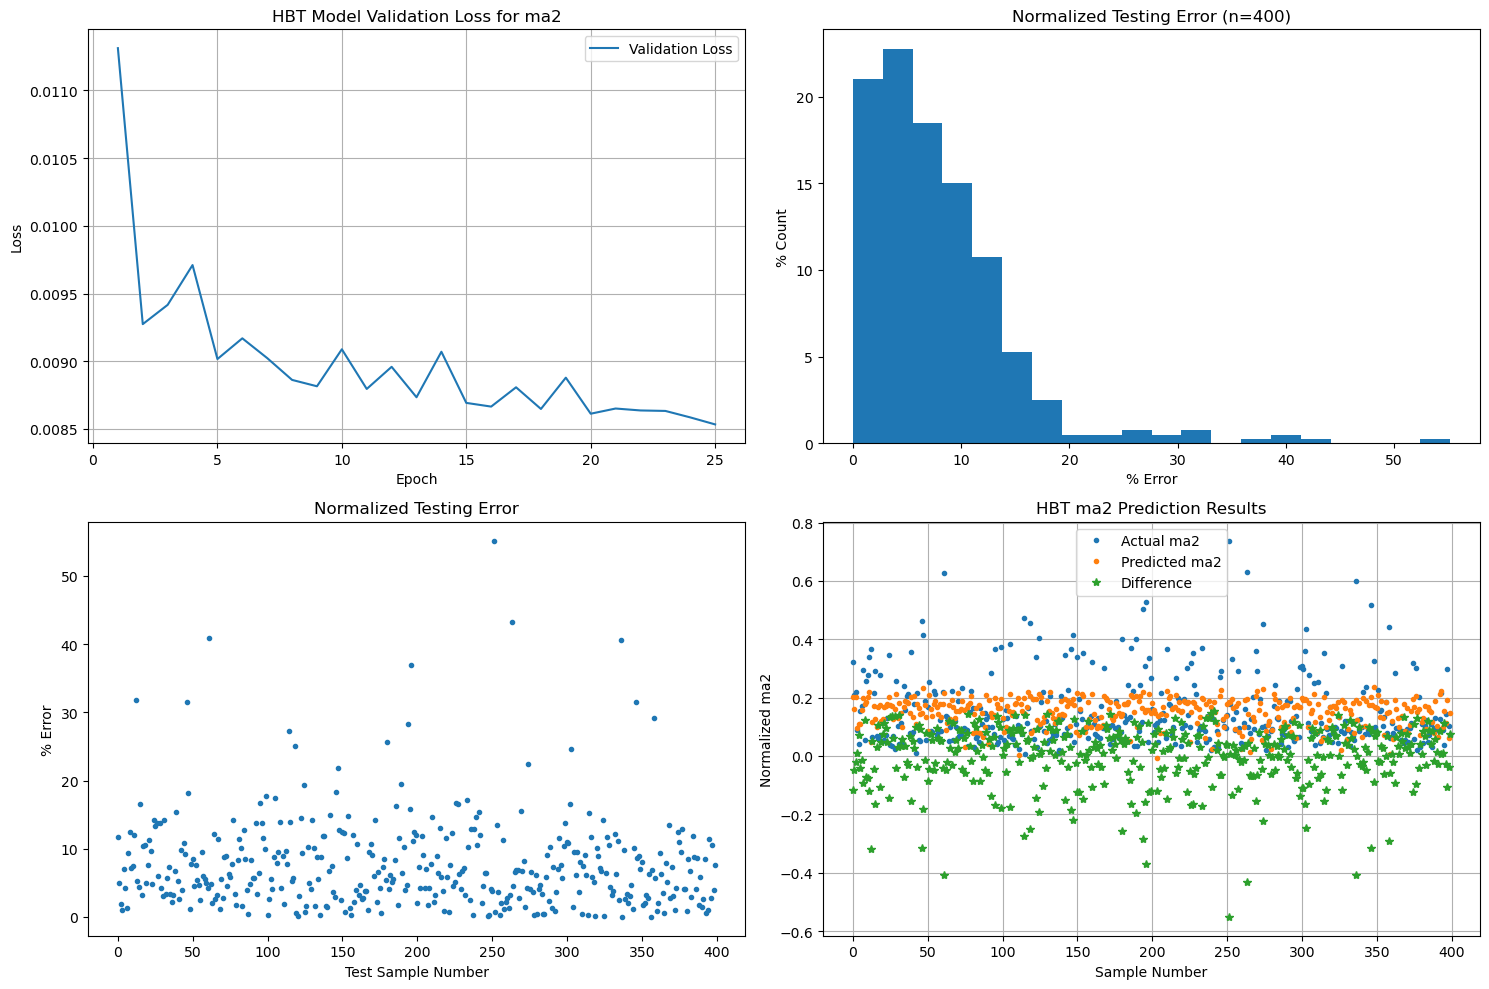

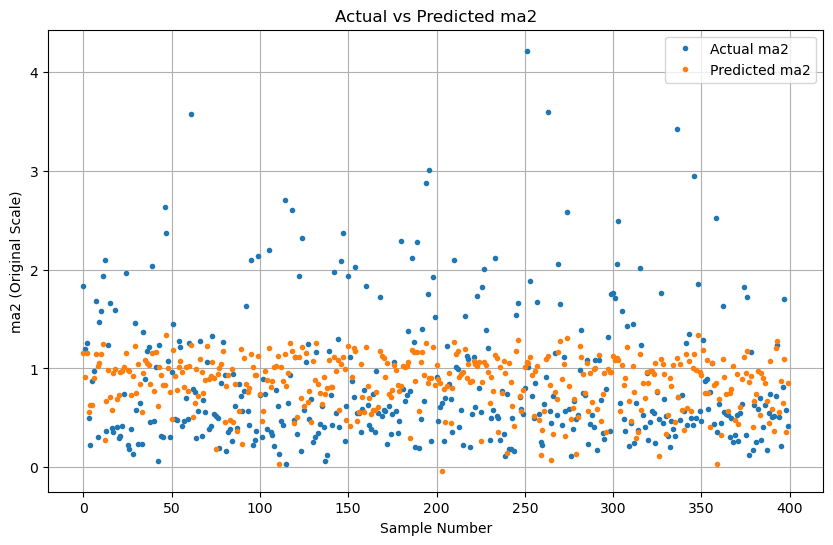

Maximum actual ma2 (normalized): 0.74
Maximum predicted ma2 (normalized): 0.23
Mean absolute percentage error: 7.76%


In [15]:
def plot_model_results(history, testing_labels, predictions, ma_norm=1.0):
    """Plot model training history, error distribution, and predictions."""
    # Normalize data
    norm_labels = np.clip(testing_labels, -1, 1)  # Already normalized, just ensure clipping
    norm_preds = np.clip(predictions[:, 0], -1, 1)
    prediction_errors = np.abs(norm_labels - norm_preds) * 100
    
    # Create figure with subplots
    fig, axes = plt.subplots(figsize=(15, 10), ncols=2, nrows=2)
    axes = axes.flatten()
    
    # Plot 1: Validation Loss
    axes[0].plot(range(1, len(history.history['val_loss']) + 1), history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'HBT Model Validation Loss for {selected_data_type}')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot 2: Error Distribution
    weights = np.ones_like(prediction_errors) / len(prediction_errors) * 100
    axes[1].hist(prediction_errors, 20, weights=weights)
    axes[1].set_xlabel('% Error')
    axes[1].set_ylabel('% Count')
    axes[1].set_title('Normalized Testing Error (n=400)')
    
    # Plot 3: Error by Sample
    axes[2].plot(prediction_errors, '.')
    axes[2].set_xlabel('Test Sample Number')  
    axes[2].set_ylabel('% Error')
    axes[2].set_title('Normalized Testing Error')
    
    # Plot 4: Actual vs Predicted
    axes[3].plot(norm_labels, '.', label=f'Actual {selected_data_type}')
    axes[3].plot(norm_preds, '.', label=f'Predicted {selected_data_type}')
    axes[3].plot(-(norm_labels - norm_preds), '*', label='Difference')
    axes[3].set_xlabel('Sample Number')
    axes[3].set_ylabel(f'Normalized {selected_data_type}')
    axes[3].set_title(f'HBT {selected_data_type} Prediction Results')
    axes[3].legend()
    axes[3].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Plot original scale predictions
    plt.figure(figsize=(10, 6))
    plt.plot(testing_labels * ma_norm, '.', label=f'Actual {selected_data_type}')
    plt.plot(predictions[:, 0] * ma_norm, '.', label=f'Predicted {selected_data_type}')
    plt.xlabel('Sample Number')
    plt.ylabel(f'{selected_data_type} (Original Scale)')
    plt.title(f'Actual vs Predicted {selected_data_type}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Print metrics
    print(f"Maximum actual {selected_data_type} (normalized): {np.max(np.abs(testing_labels)):.2f}")
    print(f"Maximum predicted {selected_data_type} (normalized): {np.max(np.abs(predictions[:, 0])):.2f}")
    print(f"Mean absolute percentage error: {np.mean(prediction_errors):.2f}%")

# Evaluate and plot
predictions = Model.predict(testing_inputs)
plot_model_results(history, testing_labels, predictions, ma_norm)

Shot 119671: Camera frames=377, HBT frames=377, Time frames=377


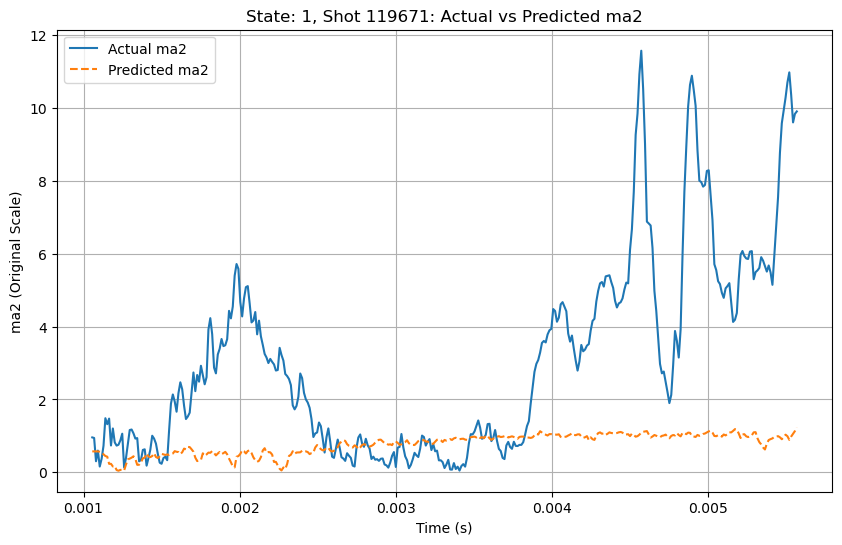

Shot 119671: HBT ma2 min/max (normalized): 0.01, 2.03
Shot 119671: HBT ma2 min/max (original): 0.05, 11.57
Shot 119671: Predicted ma2 min/max (normalized): 0.01, 0.22
Shot 119671: Predicted ma2 min/max (original): 0.04, 1.23
Shot 119671 - Mean absolute percentage error: 21.20%


In [16]:
def plot_RESERVED_SHOT_predictions(shot, shot_list, cut_training_data_2d, reserved_shot_cut_2d, target_data, model, ma_norm, reserved_shot_hbt, reserved_shot_time):
    """Plot actual vs predicted mode amplitude/phase for the reserved shot in original scale."""
    if reserved_shot_cut_2d is None or reserved_shot_hbt is None or reserved_shot_time is None:
        print(f"No data available for reserved shot {shot}. No plot generated.")
        return
    
    camera_data = reserved_shot_cut_2d
    hbt_data = reserved_shot_hbt[:, 0]
    
    print(f"Shot {shot}: Camera frames={len(camera_data)}, HBT frames={len(hbt_data)}, Time frames={len(reserved_shot_time)}")
    
    if len(camera_data) == 0:
        print(f"No camera data for shot {shot}. No plot generated.")
        return
    
    # Prepare camera data for prediction
    input_data = np.array(camera_data).reshape(-1, 32, 32, 1)
    predictions = model.predict(input_data, verbose=0)[:, 0]
    
    # Scale both actual and predicted data to original units
    hbt_data_original = hbt_data * ma_norm
    predictions_original = predictions * ma_norm
    
    # Plot actual vs predicted in original scale
    plt.figure(figsize=(10, 6))
    plt.plot(reserved_shot_time, hbt_data_original, label=f'Actual {selected_data_type}')
    plt.plot(reserved_shot_time, predictions_original, '--', label=f'Predicted {selected_data_type}')
    plt.xlabel('Time (s)')
    plt.ylabel(f'{selected_data_type} (Original Scale)')
    plt.title(f'State: {state}, Shot {shot}: Actual vs Predicted {selected_data_type}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Print metrics
    print(f"Shot {shot}: HBT {selected_data_type} min/max (normalized): {np.min(hbt_data):.2f}, {np.max(hbt_data):.2f}")
    print(f"Shot {shot}: HBT {selected_data_type} min/max (original): {np.min(hbt_data_original):.2f}, {np.max(hbt_data_original):.2f}")
    print(f"Shot {shot}: Predicted {selected_data_type} min/max (normalized): {np.min(predictions):.2f}, {np.max(predictions):.2f}")
    print(f"Shot {shot}: Predicted {selected_data_type} min/max (original): {np.min(predictions_original):.2f}, {np.max(predictions_original):.2f}")
    prediction_errors = np.abs(hbt_data_original - predictions_original) / np.max(np.abs(hbt_data_original)) * 100
    print(f"Shot {shot} - Mean absolute percentage error: {np.mean(prediction_errors):.2f}%")

    return predictions
    
reserved_predictions = plot_RESERVED_SHOT_predictions(
    RESERVED_SHOT, shot_list, cut_training_data_2D, reserved_shot_cut_2d, target_data, william_model, ma_norm, reserved_shot_hbt, reserved_shot_time
)

In [17]:
# Save true ma2 data, predictions, and time data for reserved shot
time_data = reserved_shot_time

print(f"Trimmed: Saving results for state {state}, shot {RESERVED_SHOT}")
print(f"True data defined: {'reserved_shot_hbt' in locals()}, shape: {reserved_shot_hbt[:, 0].shape if 'reserved_shot_hbt' in locals() else 'N/A'}")
print(f"Predictions defined: {'predictions' in locals()}, shape: {reserved_predictions.shape if 'predictions' in locals() else 'N/A'}")
print(f"Time data defined: {'reserved_shot_time' in locals()}, shape: {time_data.shape if 'time_data' in locals() else 'N/A'}")
np.save(f'results_{notebook_type}_state_{state}_{selected_data_type}_true.npy', reserved_shot_hbt[:, 0])
np.save(f'results_{notebook_type}_state_{state}_{selected_data_type}_pred.npy', reserved_predictions)
np.save(f'results_{notebook_type}_state_{state}_{selected_data_type}_time.npy', time_data)
print("Done")

Trimmed: Saving results for state 1, shot 119671
True data defined: True, shape: (377,)
Predictions defined: True, shape: (377,)
Time data defined: True, shape: (377,)
Done
